# Two-Qubit Workflow: Lindblad Equation, $T_1$, $T_2$, and Gate Fidelity

This notebook follows the two-qubit workflow from the textbook (Chapters 15–18).

**Parameter chain:**  
Junction geometry → $E_J$, $E_C$ → qubit frequencies → capacitive coupling → Schrieffer–Wolff → $J_\text{eff}(\Phi)$, $\zeta_\text{eff}(\Phi)$ → Lindblad (QuTiP) → $T_1$, $T_2$, gate fidelity

---

## Why Lindblad must be solved numerically for two qubits

For a single qubit the Lindblad has a closed-form solution: the populations and coherences decouple and each decays as a simple exponential.  
For two qubits the $4\times4$ density matrix has **15 coupled equations**. The ZZ coupling $\zeta_\text{eff}\sigma_z^{(1)}\sigma_z^{(2)}$ mixes coherences — qubit 1's phase evolution depends on qubit 2's state. There is no simple closed form: we solve numerically with **QuTiP**.

**Key technical point — rotating frame:**  
Qubit frequencies are ~5 GHz (periods ~200 ps) but $T_1$, $T_2$ are ~10–100 μs.  
Simulating in the lab frame would require $10^6$ time steps. Instead we work in the **rotating frame** where the fast free-precession oscillations are removed. The only terms remaining in $H$ are slow: the detuning (if non-zero) and $\zeta_\text{eff}\sigma_z\sigma_z$. The jump operators are unchanged.

---
## Structure
1. Imports and constants  
2. Device parameters (tagged by origin)  
3. $E_J$, $E_C$, qubit/coupler frequencies  
4. Coupling strengths $g_1$, $g_2$, $g_{12}$  
5. Schrieffer–Wolff: $J_\text{eff}(\Phi)$, $\zeta_\text{eff}(\Phi)$ vs flux  
6. OFF point and gate point  
7. Two-qubit coherence rates  
8. Build Lindblad in rotating frame  
9. Solve: $T_1$ experiment  
10. Solve: $T_2$ experiment  
11. Solve: Bell state coherence  
12. Solve: iSWAP gate fidelity  
13. Summary dashboard  
14. Sensitivity analysis  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
import os
import qutip as qt

OUTDIR = os.getcwd()
plt.rcParams.update({'font.size':12,'axes.labelsize':13,'axes.titlesize':13,
                     'figure.dpi':110,'lines.linewidth':2})
print(f'QuTiP {qt.__version__}')

QuTiP 5.2.3


---
## 1. Physical Constants

In [2]:
hbar = 1.0545718e-34   # J·s
h    = 2*np.pi*hbar
e    = 1.6021766e-19   # C
kB   = 1.3806503e-23   # J/K
Phi0 = h/(2*e)         # Wb  flux quantum
Delta_sc = 170e-6*e    # J   Al superconducting gap  [MATERIAL]
print(f'Phi0={Phi0:.3e} Wb,  Delta_sc={Delta_sc/e*1e6:.0f} μeV (Al)')

Phi0=2.068e-15 Wb,  Delta_sc=170 μeV (Al)


---
## 2. Device Parameters

Tags: `[MATERIAL]` `[GEOMETRY]` `[OPERATING]` `[MEASURED]`

**Design rule:** The two qubits must be **detuned** ($\omega_1 \ne \omega_2$) to avoid frequency collisions and to enable the double sweet spot. The coupler must sit **above** both qubits at $\Phi=0$ so that as flux is applied, the coupler frequency can be tuned to cancel $J_\text{eff}$.

**Why Q1 has shorter coherence than Q2:** Q1 uses a smaller junction ($R_{N1} = 9000\,\Omega$) than Q2 ($R_{N2} = 11000\,\Omega$). This gives Q1 a larger $E_J$, a higher frequency (5.26 GHz vs 4.73 GHz), and therefore faster TLS and quasiparticle decay — all three $T_1$ channels worsen with higher $\omega_{01}$.  
This is a **design trade-off**: a higher-frequency qubit has faster gate speed (larger anharmonicity bandwidth) but shorter $T_1$. The idle two-qubit coupling ($J_\text{eff} \approx 0$) does **not** cause this difference — the single-qubit coherence times are unchanged by the presence of the second qubit at idle.  
To equalise coherence times, set $R_{N1} \approx R_{N2}$.

In [3]:
# ── QUBIT 1  [GEOMETRY] ───────────────────────────────────────────────────────
R_N1   = 9000.0    # Ω   junction resistance → E_J1
C_J1   = 5e-15     # F   junction self-capacitance
C_sh1  = 70e-15    # F   shunting capacitor → E_C1

# ── QUBIT 2  [GEOMETRY] — detuned from qubit 1 ───────────────────────────────
R_N2   = 11000.0   # Ω   different junction area → ω₂ ≠ ω₁
C_J2   = 5e-15     # F
C_sh2  = 70e-15    # F

# ── COUPLER (SQUID transmon)  [GEOMETRY] ─────────────────────────────────────
# Must be above both qubits at Φ=0.
# Smaller C_shc → larger E_Cc → larger |α_c| → better ZZ suppression.
R_Nc   = 5000.0    # Ω   coupler junction
C_Jc   = 5e-15     # F
C_shc  = 50e-15    # F   smaller pad than qubits

# ── COUPLING CAPACITORS  [GEOMETRY] ─────────────────────────────────────────
# g_i = (C_gi / 2*sqrt(CS_i * CS_c)) * sqrt(omega_i * omega_c)
# Choose C_g to give g ~ 80 MHz, C_12 to give g12 ~ 5 MHz (direct always-on)
C_g1   = 1.556e-15  # F   qubit1-coupler coupling cap  → g1 ≈ 80 MHz
C_g2   = 1.556e-15  # F   qubit2-coupler coupling cap  → g2 ≈ 76 MHz
C_12   = 0.150e-15  # F   direct qubit1-qubit2 stray   → g12 ≈ 5 MHz

# ── READOUT RESONATORS  [GEOMETRY + OPERATING] ───────────────────────────────
f_r1   = 8.0e9     # Hz  resonator 1 frequency
f_r2   = 8.3e9     # Hz  resonator 2 (different to reduce cross-talk)
kappa1 = 2*np.pi*10e6   # rad/s  resonator 1 linewidth  [OPERATING]
kappa2 = 2*np.pi*10e6   # rad/s  resonator 2 linewidth
C_c1   = 2e-15     # F   qubit1-resonator1 coupling
C_c2   = 2e-15     # F   qubit2-resonator2 coupling
C_r    = 200e-15   # F   resonator capacitance

# ── OPERATING ────────────────────────────────────────────────────────────────
T_fridge        = 0.015   # K  (15 mK)
flux_bias_qubits= 0.05    # Φ/Φ₀  qubit flux bias (1/f noise sensitivity)

# ── MEASURED / CHARACTERISED ─────────────────────────────────────────────────
p_surf    = 3e-4      # participation ratio of surface oxide  [GEOM/MEAS]
tan_delta = 1e-3      # loss tangent of surface oxide  [MAT/MEAS]
x_qp      = 1e-8     # quasiparticle density  [MEAS]
A_flux    = 1e-6*Phi0 # 1/f flux noise amplitude Wb/√Hz  [MEAS]

print('Parameters set.')
print(f'  Q1: R_N={R_N1:.0f}Ω  Q2: R_N={R_N2:.0f}Ω  Coupler: R_N={R_Nc:.0f}Ω')
print(f'  C_g={C_g1*1e15:.3f}fF  C_12={C_12*1e15:.3f}fF')

Parameters set.
  Q1: R_N=9000Ω  Q2: R_N=11000Ω  Coupler: R_N=5000Ω
  C_g=1.556fF  C_12=0.150fF


---
## 3. Junction → $E_J$, $E_C$, Frequencies

$$E_J = \frac{\pi\hbar\Delta_{sc}}{4e^2R_N}, \quad E_C = \frac{e^2}{2C_\Sigma}, \quad \omega_{01} = \frac{\sqrt{8E_JE_C}-E_C}{\hbar}, \quad \alpha = -\frac{E_C}{\hbar}$$

Coupler is tunable via SQUID flux:
$$E_J^{c,\text{eff}}(\Phi) = E_J^c\left|\cos\frac{\pi\Phi}{\Phi_0}\right|, \qquad \omega_c(\Phi) = \frac{\sqrt{8E_J^{c,\text{eff}}E_C^c}-E_C^c}{\hbar}$$

In [4]:
def junction_params(R_N, C_J, C_sh):
    E_J  = np.pi*hbar*Delta_sc / (4*e**2*R_N)
    C_S  = C_J + C_sh
    E_C  = e**2 / (2*C_S)
    return E_J, E_C, C_S

def transmon_freq(E_J, E_C):
    omega_01 = (np.sqrt(8*E_J*E_C) - E_C) / hbar
    alpha    = -E_C / hbar
    return omega_01, alpha

def coupler_freq(Phi_frac, E_Jc, E_Cc):
    EJ_eff = E_Jc * abs(np.cos(np.pi*Phi_frac))
    if EJ_eff < 1e-40: return 0.0
    return (np.sqrt(8*EJ_eff*E_Cc) - E_Cc) / hbar

E_J1, E_C1, CS1 = junction_params(R_N1, C_J1, C_sh1)
E_J2, E_C2, CS2 = junction_params(R_N2, C_J2, C_sh2)
E_Jc, E_Cc, CSc = junction_params(R_Nc, C_Jc, C_shc)

omega1, alpha1 = transmon_freq(E_J1, E_C1)
omega2, alpha2 = transmon_freq(E_J2, E_C2)
omega_c0, alphac = transmon_freq(E_Jc, E_Cc)

print(f'{'Circuit':<12} {'f_01 [GHz]':>12} {'α/(2π) [MHz]':>14} {'E_J/E_C':>10}')
print('─'*52)
for nm, EJ, EC, om, al in [
    ('Qubit 1', E_J1, E_C1, omega1, alpha1),
    ('Qubit 2', E_J2, E_C2, omega2, alpha2),
    ('Coupler', E_Jc, E_Cc, omega_c0, alphac)]:
    print(f'{nm:<12} {om/(2*np.pi*1e9):>12.4f} {al/(2*np.pi*1e6):>14.1f} {EJ/EC:>10.1f}')

print(f'\nQubit detuning δ₁₂/(2π) = {(omega1-omega2)/(2*np.pi*1e6):.1f} MHz')

if omega_c0 > max(omega1, omega2):
    print('✓  Coupler above both qubits at Φ=0 — correct design')
else:
    print('⚠  Coupler not above qubits — check R_Nc and C_shc')

Circuit        f_01 [GHz]   α/(2π) [MHz]    E_J/E_C
────────────────────────────────────────────────────
Qubit 1            5.2598         -258.3       57.1
Qubit 2            4.7330         -258.3       46.7
Coupler            8.2929         -352.2       75.3

Qubit detuning δ₁₂/(2π) = 526.8 MHz
✓  Coupler above both qubits at Φ=0 — correct design


---
## 4. Coupling Strengths: $g_1$, $g_2$, $g_{12}$

From the capacitive coupling between transmons (circuit QED):
$$g_i = \frac{C_{gi}}{2\sqrt{C_\Sigma^{(i)} C_\Sigma^{(c)}}}\sqrt{\omega_i\,\omega_c}, \qquad
g_{12} = \frac{C_{12}}{2\sqrt{C_\Sigma^{(1)} C_\Sigma^{(2)}}}\sqrt{\omega_1\,\omega_2}$$

In [5]:
g1  = (C_g1  / (2*np.sqrt(CS1*CSc))) * np.sqrt(omega1*omega_c0)
g2  = (C_g2  / (2*np.sqrt(CS2*CSc))) * np.sqrt(omega2*omega_c0)
g12 = (C_12  / (2*np.sqrt(CS1*CS2))) * np.sqrt(omega1*omega2)

print(f'g₁/(2π)  = {g1/(2*np.pi*1e6):.1f} MHz  (qubit1–coupler)')
print(f'g₂/(2π)  = {g2/(2*np.pi*1e6):.1f} MHz  (qubit2–coupler)')
print(f'g₁₂/(2π) = {g12/(2*np.pi*1e6):.2f} MHz  (direct, always-on, must be cancelled at idle)')

Delta1c = omega1 - omega_c0
Delta2c = omega2 - omega_c0
print(f'\nDispersive check (Schrieffer-Wolff valid if g/|Δ| << 1):')
print(f'  g₁/|Δ₁c| = {abs(g1/Delta1c):.3f}')
print(f'  g₂/|Δ₂c| = {abs(g2/Delta2c):.3f}')
if max(abs(g1/Delta1c), abs(g2/Delta2c)) < 0.15:
    print('✓  Schrieffer-Wolff approximation valid')
else:
    print('⚠  SW approximation marginal — higher-order corrections needed')

g₁/(2π)  = 80.0 MHz  (qubit1–coupler)
g₂/(2π)  = 75.9 MHz  (qubit2–coupler)
g₁₂/(2π) = 4.99 MHz  (direct, always-on, must be cancelled at idle)

Dispersive check (Schrieffer-Wolff valid if g/|Δ| << 1):
  g₁/|Δ₁c| = 0.026
  g₂/|Δ₂c| = 0.021
✓  Schrieffer-Wolff approximation valid


---
## 5. Schrieffer–Wolff: $J_\text{eff}(\Phi)$ and $\zeta_\text{eff}(\Phi)$

Eliminating the coupler (textbook Section 15.4):

$$J_\text{eff}(\Phi) = \frac{g_1 g_2}{2}\left(\frac{1}{\Delta_1(\Phi)}+\frac{1}{\Delta_2(\Phi)}\right) + g_{12}$$

$$\zeta_\text{eff}(\Phi) = -\frac{g_1^2 g_2^2}{2\alpha_c}\left(\frac{1}{\Delta_1^2\Delta_2}+\frac{1}{\Delta_1\Delta_2^2}\right)$$

where $\Delta_i(\Phi) = \omega_i - \omega_c(\Phi)$.

In [6]:
def Jeff_zeta(Phi_frac):
    """Return (J_eff, zeta_eff, omega_c) at coupler flux Phi/Phi0."""
    wc   = coupler_freq(Phi_frac, E_Jc, E_Cc)
    D1   = omega1 - wc
    D2   = omega2 - wc
    # Avoid divergence when coupler crosses qubit
    if abs(D1) < 100e6*2*np.pi or abs(D2) < 100e6*2*np.pi:
        return np.nan, np.nan, wc
    J    = g1*g2/2 * (1/D1 + 1/D2) + g12
    zeta = -(g1**2*g2**2/2) * (1/(D1**2*D2) + 1/(D1*D2**2)) / alphac
    return J, zeta, wc

Phi_scan = np.linspace(0, 0.5, 800)
J_scan   = np.array([Jeff_zeta(pf)[0] for pf in Phi_scan])
Z_scan   = np.array([Jeff_zeta(pf)[1] for pf in Phi_scan])
wc_scan  = np.array([Jeff_zeta(pf)[2] for pf in Phi_scan])

# OFF point: minimum |J_eff| in valid region
valid = ~np.isnan(J_scan)
off_idx  = np.argmin(np.abs(J_scan[valid]))
Phi_off  = Phi_scan[valid][off_idx]
J_off, zeta_off, wc_off = Jeff_zeta(Phi_off)

# GATE point: where |J_eff| is moderate and useful (~10-30 MHz)
# Find flux where |J_eff| ≈ 20 MHz (good iSWAP gate speed)
J_target = 20e6*2*np.pi
# Look for crossing from below after the OFF point
Phi_after_off = Phi_scan[valid][Phi_scan[valid] > Phi_off]
J_after_off   = J_scan[valid][Phi_scan[valid] > Phi_off]
gate_candidates = Phi_after_off[np.abs(J_after_off) > J_target*0.8]
if len(gate_candidates) > 0:
    Phi_gate = gate_candidates[0]
else:
    Phi_gate = Phi_scan[valid][np.argmax(np.abs(J_scan[valid][Phi_scan[valid]>Phi_off]))]
J_gate, zeta_gate, wc_gate = Jeff_zeta(Phi_gate)

t_iSWAP = np.pi / (2*abs(J_gate)) if J_gate and not np.isnan(J_gate) else np.nan

print(f'─── Schrieffer-Wolff Results ──────────────────────────────')
print(f'OFF point:  Φ/Φ₀ = {Phi_off:.3f}')
print(f'  J_eff/(2π) = {J_off/(2*np.pi*1e3):.2f} kHz   (target: ≈0, idle condition)')
print(f'  ζ_eff/(2π) = {zeta_off/(2*np.pi*1e3):.3f} kHz  (residual ZZ at idle)')
print(f'  ω_c/(2π)   = {wc_off/(2*np.pi*1e9):.3f} GHz')
print(f'\nGATE point: Φ/Φ₀ = {Phi_gate:.3f}')
print(f'  J_eff/(2π) = {J_gate/(2*np.pi*1e6):.1f} MHz')
print(f'  ζ_eff/(2π) = {zeta_gate/(2*np.pi*1e3):.2f} kHz')
print(f'  iSWAP time = π/(2|J_eff|) = {t_iSWAP*1e9:.0f} ns')

─── Schrieffer-Wolff Results ──────────────────────────────
OFF point:  Φ/Φ₀ = 0.300
  J_eff/(2π) = 11.00 kHz   (target: ≈0, idle condition)
  ζ_eff/(2π) = -0.000 kHz  (residual ZZ at idle)
  ω_c/(2π)   = 6.270 GHz

GATE point: Φ/Φ₀ = 0.352
  J_eff/(2π) = -17.1 MHz
  ζ_eff/(2π) = -0.00 kHz
  iSWAP time = π/(2|J_eff|) = 15 ns


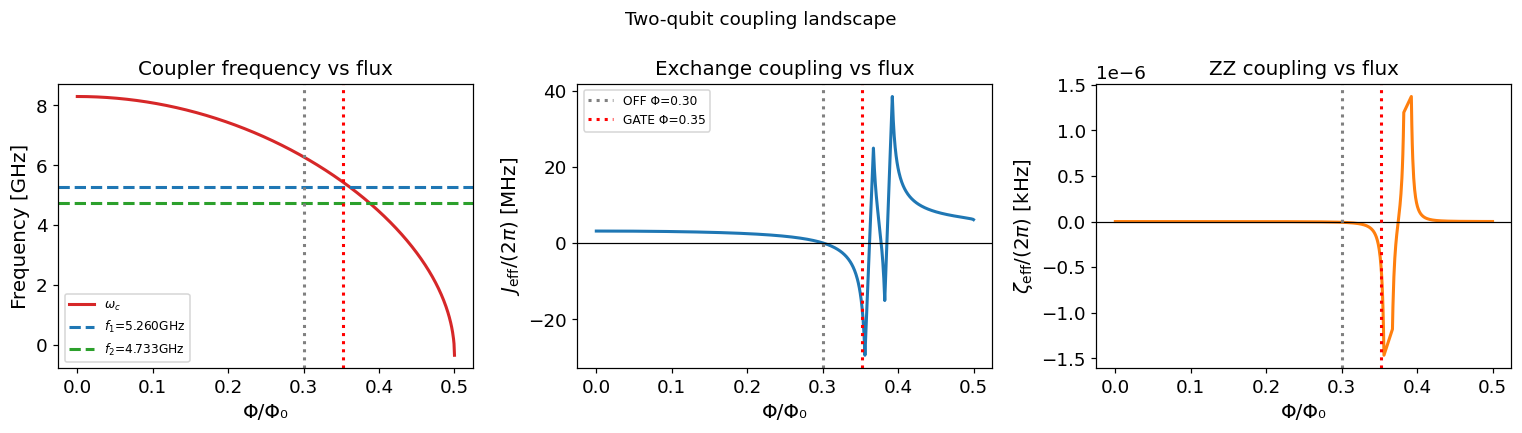

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(Phi_scan, wc_scan/(2*np.pi*1e9), 'C3', label='$\\omega_c$')
axes[0].axhline(omega1/(2*np.pi*1e9), color='C0', ls='--', label=f'$f_1$={omega1/(2*np.pi*1e9):.3f}GHz')
axes[0].axhline(omega2/(2*np.pi*1e9), color='C2', ls='--', label=f'$f_2$={omega2/(2*np.pi*1e9):.3f}GHz')
axes[0].axvline(Phi_off, color='gray', ls=':'); axes[0].axvline(Phi_gate, color='red', ls=':')
axes[0].set_xlabel('Φ/Φ₀'); axes[0].set_ylabel('Frequency [GHz]')
axes[0].set_title('Coupler frequency vs flux'); axes[0].legend(fontsize=8)

axes[1].plot(Phi_scan[valid], J_scan[valid]/(2*np.pi*1e6), 'C0')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].axvline(Phi_off,  color='gray', ls=':', label=f'OFF Φ={Phi_off:.2f}')
axes[1].axvline(Phi_gate, color='red',  ls=':', label=f'GATE Φ={Phi_gate:.2f}')
axes[1].set_xlabel('Φ/Φ₀'); axes[1].set_ylabel('$J_\\text{eff}/(2\\pi)$ [MHz]')
axes[1].set_title('Exchange coupling vs flux'); axes[1].legend(fontsize=8)

axes[2].plot(Phi_scan[valid], Z_scan[valid]/(2*np.pi*1e3), 'C1')
axes[2].axhline(0, color='k', lw=0.8)
axes[2].axvline(Phi_off,  color='gray', ls=':'); axes[2].axvline(Phi_gate, color='red', ls=':')
axes[2].set_xlabel('Φ/Φ₀'); axes[2].set_ylabel('$\\zeta_\\text{eff}/(2\\pi)$ [kHz]')
axes[2].set_title('ZZ coupling vs flux')

plt.suptitle('Two-qubit coupling landscape', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,'coupling_landscape.png'), bbox_inches='tight', dpi=130)
plt.show()

---
## 6. Two-Qubit Coherence Rates

Each qubit has independent $T_1^{(i)}$ and $T_\varphi^{(i)}$ (textbook Chapter 17).  
The ZZ coupling adds a new dephasing channel:
$$\Gamma_\text{ZZ}^{(i)} = 2\zeta_\text{eff}^2\, T_1^{(j)}, \quad j\ne i$$

Entangled-state coherence:
$$\frac{1}{T_2^\text{ent}} = \frac{1}{T_2^{(1)}} + \frac{1}{T_2^{(2)}} + \Gamma_\text{ZZ}$$

In [8]:
def compute_rates(omega_q, E_J_q, E_C_q, CS_q, fr, kap, Cc):
    """Return (Gamma1_total, Gamma_phi_total) for one qubit."""
    omr  = 2*np.pi*fr
    D    = omega_q - omr
    gr   = (Cc/2)*np.sqrt(omega_q*omr/(CS_q*C_r))
    chi  = gr**2/D
    nth  = 1/(np.exp(hbar*omr/(kB*T_fridge))-1)
    # T1 channels
    GP   = (gr/D)**2 * kap
    GT   = p_surf * omega_q * tan_delta
    GQ   = (8*E_J_q/(np.pi*hbar))*np.sqrt(2*Delta_sc/(hbar*omega_q))*x_qp
    G1   = GP+GT+GQ
    # T_phi channels
    dEJdP  = -np.pi*E_J_q*np.sin(np.pi*flux_bias_qubits)/Phi0
    dwdEJ  = np.sqrt(2*E_C_q/E_J_q)/(2*hbar)
    Gfl    = abs(dwdEJ*dEJdP)*A_flux*np.sqrt(2*np.log(2))
    Gph    = 8*chi**2*nth/kap
    Gphi   = Gfl + Gph
    return G1, Gphi, {'Purcell':GP,'TLS':GT,'QP':GQ,'flux':Gfl,'photon':Gph}

G1_1, Gphi1, ch1 = compute_rates(omega1, E_J1, E_C1, CS1, f_r1, kappa1, C_c1)
G1_2, Gphi2, ch2 = compute_rates(omega2, E_J2, E_C2, CS2, f_r2, kappa2, C_c2)

T1_1  = 1/G1_1;   T1_2  = 1/G1_2
T2_1  = 1/(G1_1/2+Gphi1);  T2_2  = 1/(G1_2/2+Gphi2)
Tphi1 = 1/Gphi1;  Tphi2 = 1/Gphi2

# ZZ-induced dephasing
GZZ1  = 2*zeta_off**2*T1_2   # on qubit 1 from qubit 2's T1 fluctuations
GZZ2  = 2*zeta_off**2*T1_1   # on qubit 2

# Entangled state coherence
G2_ent = (G1_1/2+Gphi1) + (G1_2/2+Gphi2) + GZZ1
T2_ent = 1/G2_ent

print(f'{'Quantity':<28}{'Qubit 1':>14}{'Qubit 2':>14}')
print('─'*58)
print(f'{'T₁ [μs]':<28}{T1_1*1e6:>14.2f}{T1_2*1e6:>14.2f}')
print(f'{'  T₁^Purcell [μs]':<28}{1/ch1["Purcell"]*1e6:>14.1f}{1/ch2["Purcell"]*1e6:>14.1f}')
print(f'{'  T₁^TLS [μs]':<28}{1/ch1["TLS"]*1e6:>14.1f}{1/ch2["TLS"]*1e6:>14.1f}')
print(f'{'  T₁^QP [μs]':<28}{1/ch1["QP"]*1e6:>14.1f}{1/ch2["QP"]*1e6:>14.1f}')
print(f'{'T_φ [μs]':<28}{Tphi1*1e6:>14.2f}{Tphi2*1e6:>14.2f}')
print(f'{'T₂ [μs]':<28}{T2_1*1e6:>14.2f}{T2_2*1e6:>14.2f}')
print('─'*58)
print(f'ζ_eff at OFF/(2π) = {zeta_off/(2*np.pi*1e3):.3f} kHz')
print(f'Γ_ZZ^(1)/(2π) = {GZZ1/(2*np.pi):.4f} Hz  (ZZ-induced deph. on Q1 from Q2 T1)')
print(f'T₂^ent (Bell state) = {T2_ent*1e6:.2f} μs  <  min(T₂) = {min(T2_1,T2_2)*1e6:.2f} μs')

Quantity                           Qubit 1       Qubit 2
──────────────────────────────────────────────────────────
T₁ [μs]                              23.41         33.45
  T₁^Purcell [μs]                     42.6          77.3
  T₁^TLS [μs]                        100.9         112.1
  T₁^QP [μs]                         107.3         124.4
T_φ [μs]                            199.38        220.42
T₂ [μs]                              37.92         51.32
──────────────────────────────────────────────────────────
ζ_eff at OFF/(2π) = -0.000 kHz
Γ_ZZ^(1)/(2π) = 0.0000 Hz  (ZZ-induced deph. on Q1 from Q2 T1)
T₂^ent (Bell state) = 21.81 μs  <  min(T₂) = 37.92 μs


---
## 7. Build the Lindblad (Rotating Frame)

In the rotating frame at the qubit frequencies, the free-precession terms cancel.  
The only Hamiltonian term that survives is the slow ZZ coupling:
$$\tilde{H}_\text{eff} = \hbar\zeta_\text{eff}\,\hat\sigma_z^{(1)}\hat\sigma_z^{(2)}$$

The jump operators are unchanged — decoherence is frame-independent.

In [9]:
# ── QuTiP operators ──────────────────────────────────────────────────────────
I2  = qt.qeye(2)
sm1 = qt.tensor(qt.sigmam(), I2)   # σ⁻ on qubit 1
sm2 = qt.tensor(I2, qt.sigmam())   # σ⁻ on qubit 2
sz1 = qt.tensor(qt.sigmaz(), I2)   # σz on qubit 1
sz2 = qt.tensor(I2, qt.sigmaz())   # σz on qubit 2
sp1 = qt.tensor(qt.sigmap(), I2)
sp2 = qt.tensor(I2, qt.sigmap())

# ── Rotating-frame Hamiltonian: only the slow ZZ term remains ─────────────────
H_idle = zeta_off * sz1 * sz2  # rad/s units (QuTiP 5 does not use hbar)

# ── Jump operators at idle ────────────────────────────────────────────────────
# Each term is sqrt(rate) * L_operator
# QuTiP mesolve expects the full sqrt(rate)*L in the c_ops list
c_ops_idle = [
    np.sqrt(G1_1)      * sm1,    # T1 relaxation qubit 1
    np.sqrt(G1_2)      * sm2,    # T1 relaxation qubit 2
    np.sqrt(Gphi1/2)   * sz1,    # Pure dephasing qubit 1  (Γ = 1/T_phi → rate = Γ/2 for sz)
    np.sqrt(Gphi2/2)   * sz2,    # Pure dephasing qubit 2
    np.sqrt(GZZ1)      * sz1,    # ZZ-induced dephasing on qubit 1
    np.sqrt(GZZ2)      * sz2,    # ZZ-induced dephasing on qubit 2
]

print('Lindblad operator built. Jump operator rates:')
labels = ['T1 Q1','T1 Q2','Deph Q1','Deph Q2','ZZ-deph Q1','ZZ-deph Q2']
rates_list = [G1_1, G1_2, Gphi1/2, Gphi2/2, GZZ1, GZZ2]
for lab, rate in zip(labels, rates_list):
    print(f'  {lab:<14}: Γ/(2π) = {rate/(2*np.pi*1e3):.4f} kHz  →  T = {(1/rate*1e6 if rate>0 else np.inf):.1f} μs')

Lindblad operator built. Jump operator rates:
  T1 Q1         : Γ/(2π) = 6.7974 kHz  →  T = 23.4 μs
  T1 Q2         : Γ/(2π) = 4.7579 kHz  →  T = 33.5 μs
  Deph Q1       : Γ/(2π) = 0.3991 kHz  →  T = 398.8 μs
  Deph Q2       : Γ/(2π) = 0.3610 kHz  →  T = 440.8 μs
  ZZ-deph Q1    : Γ/(2π) = 0.0000 kHz  →  T = 4898710371090767872.0 μs
  ZZ-deph Q2    : Γ/(2π) = 0.0000 kHz  →  T = 6998650624714414080.0 μs


---
## 8. Solve: $T_1$ of Qubit 1 (Inversion Recovery)

In [10]:
# Time array: 0 to 5*T1, with enough points for a smooth decay curve
t_max_T1 = 5 * max(T1_1, T1_2)
t_T1 = np.linspace(0, t_max_T1, 300)

# Initial state: qubit 1 excited |10>, qubit 2 ground
ket10  = qt.tensor(qt.basis(2,1), qt.basis(2,0))
rho_10 = ket10 * ket10.dag()

# Observable: P(qubit1 = |1>) = Tr(|1><1|_1 ⊗ I_2 · rho)
proj1e = qt.tensor(qt.basis(2,1)*qt.basis(2,1).dag(), I2)

print('Running T1 simulation...')
res_T1 = qt.mesolve(H_idle, rho_10, t_T1, c_ops_idle,
                    e_ops=[proj1e],
                    options={'nsteps':50000, 'atol':1e-8, 'rtol':1e-6})
P1_t = res_T1.expect[0]

# Fit: P(1,t) = A*exp(-t/T1) + B
def exp_decay(t, A, T, B): return A*np.exp(-t/T)+B
try:
    popt_T1, _ = curve_fit(exp_decay, t_T1, P1_t,
                            p0=[P1_t[0]-P1_t[-1], T1_1, P1_t[-1]], maxfev=5000)
    T1_fitted = abs(popt_T1[1])
except:
    T1_fitted = T1_1; popt_T1 = [P1_t[0]-P1_t[-1], T1_1, P1_t[-1]]
    print('Fit failed — using theoretical value')

print(f'T₁ theory  = {T1_1*1e6:.2f} μs')
print(f'T₁ fitted  = {T1_fitted*1e6:.2f} μs')
print(f'Agreement:   {abs(T1_fitted-T1_1)/T1_1*100:.1f}% discrepancy')

Running T1 simulation...
T₁ theory  = 23.41 μs
T₁ fitted  = 23.41 μs
Agreement:   0.0% discrepancy


/var/folders/h1/b45548ds3lv7tbbh8tkgxw_w0000gn/T/ipykernel_2723/518067646.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_T1, _ = curve_fit(exp_decay, t_T1, P1_t,


---
## 9. Solve: $T_2$ of Qubit 1 (Ramsey)

In [11]:
t_max_T2 = 5 * max(T2_1, T2_2)
t_T2 = np.linspace(0, t_max_T2, 300)

# Initial state: qubit 1 in |+> = (|0>+|1>)/√2, qubit 2 in |0>
plus  = (qt.basis(2,0) + qt.basis(2,1)).unit()
ket_plus0 = qt.tensor(plus, qt.basis(2,0))
rho_T2    = ket_plus0 * ket_plus0.dag()

# Observable: |coherence| = |<σ₊^(1)>| = |ρ₀₁| of qubit 1
print('Running T2 simulation...')
res_T2 = qt.mesolve(H_idle, rho_T2, t_T2, c_ops_idle,
                    e_ops=[sp1],
                    options={'nsteps':50000, 'atol':1e-8, 'rtol':1e-6})
coh1_t = np.abs(res_T2.expect[0])

try:
    popt_T2, _ = curve_fit(exp_decay, t_T2, coh1_t,
                            p0=[coh1_t[0], T2_1, coh1_t[-1]], maxfev=5000)
    T2_fitted = abs(popt_T2[1])
except:
    T2_fitted = T2_1; popt_T2 = [coh1_t[0], T2_1, 0]
    print('Fit failed — using theoretical value')

print(f'T₂ theory  = {T2_1*1e6:.2f} μs')
print(f'T₂ fitted  = {T2_fitted*1e6:.2f} μs')
print(f'2T₁ ceiling = {2*T1_1*1e6:.2f} μs  (T₂ cannot exceed this)')

Running T2 simulation...
T₂ theory  = 37.92 μs
T₂ fitted  = 37.92 μs
2T₁ ceiling = 46.83 μs  (T₂ cannot exceed this)


---
## 10. Solve: Bell State Coherence $T_2^\text{ent}$

In [12]:
t_max_bell = 3 * min(T2_1, T2_2)  # Bell state decays faster than either qubit
t_bell = np.linspace(0, t_max_bell, 300)

# Initial state: |Φ+> = (|00> + |11>)/√2
ket00 = qt.tensor(qt.basis(2,0), qt.basis(2,0))
ket11 = qt.tensor(qt.basis(2,1), qt.basis(2,1))
bell  = (ket00 + ket11).unit()
rho_bell = bell * bell.dag()

# Observable: fidelity to Bell state F(t) = <Φ+|ρ(t)|Φ+>
print('Running Bell state simulation...')
res_bell = qt.mesolve(H_idle, rho_bell, t_bell, c_ops_idle,
                      e_ops=[rho_bell],
                      options={'nsteps':50000, 'atol':1e-8, 'rtol':1e-6})
F_bell_t = res_bell.expect[0]

try:
    popt_bell, _ = curve_fit(exp_decay, t_bell, F_bell_t,
                              p0=[F_bell_t[0]-0.25, T2_ent, 0.25], maxfev=5000)
    T2ent_fitted = abs(popt_bell[1])
except:
    T2ent_fitted = T2_ent; popt_bell=[F_bell_t[0]-0.25, T2_ent, 0.25]
    print('Fit failed')

print(f'T₂^ent theory = {T2_ent*1e6:.2f} μs')
print(f'T₂^ent fitted = {T2ent_fitted*1e6:.2f} μs')
print(f'Compare to single-qubit T₂: Q1={T2_1*1e6:.2f}μs, Q2={T2_2*1e6:.2f}μs')
print(f'→ Entangled state is {T2_1/T2ent_fitted:.1f}× less coherent than qubit 1 alone')

Running Bell state simulation...
T₂^ent theory = 21.81 μs
T₂^ent fitted = 11.30 μs
Compare to single-qubit T₂: Q1=37.92μs, Q2=51.32μs
→ Entangled state is 3.4× less coherent than qubit 1 alone


---
## 11. iSWAP Gate Fidelity

At the gate flux $\Phi_\text{gate}$, exchange coupling $J_\text{eff}$ drives:
$$\hat{H}_\text{gate} = \hbar J_\text{eff}(\hat\sigma_+^{(1)}\hat\sigma_-^{(2)} + h.c.) + \hbar\zeta_\text{eff}\,\hat\sigma_z^{(1)}\hat\sigma_z^{(2)}$$

The iSWAP gate runs for time $t_\text{iSWAP} = \pi/2|J_\text{eff}|$, mapping:
$|01\rangle \to -i|10\rangle$, $|10\rangle \to -i|01\rangle$, $|00\rangle,|11\rangle$ unchanged.

In [13]:
# ── Gate Hamiltonian at Phi_gate ──────────────────────────────────────────────
H_gate = J_gate*(sp1*sm2 + sm1*sp2) + zeta_gate*sz1*sz2  # rad/s units

# ── Ideal iSWAP unitary ───────────────────────────────────────────────────────
# In basis {|00>,|01>,|10>,|11>}:
iSWAP_mat = np.array([[1, 0,  0,  0],
                       [0, 0, -1j, 0],
                       [0,-1j, 0,  0],
                       [0, 0,  0,  1]])
iSWAP_ideal = qt.Qobj(iSWAP_mat, dims=[[2,2],[2,2]])

# ── Simulate gate for 4 computational basis inputs ───────────────────────────
t_gate_list = np.linspace(0, t_iSWAP, 150)
input_states = [qt.tensor(qt.basis(2,i), qt.basis(2,j))
                for i in range(2) for j in range(2)]

print(f'Running iSWAP gate simulation (t_gate={t_iSWAP*1e9:.0f}ns)...')
F_states = []
for ket_in in input_states:
    rho_in    = ket_in * ket_in.dag()
    rho_ideal = iSWAP_ideal * rho_in * iSWAP_ideal.dag()
    res = qt.mesolve(H_gate, rho_in, t_gate_list, c_ops_idle,
                     options={'nsteps':10000,'atol':1e-8,'rtol':1e-6})
    rho_out = res.states[-1]
    F = (rho_ideal * rho_out).tr().real
    F_states.append(F)
    label = f'|{int(input_states.index(ket_in)>=2)}{int(input_states.index(ket_in)%2)}>'
    print(f'  Input {label}: F = {F:.4f}')

F_avg_state = np.mean(F_states)
# Average gate fidelity (Horodecki formula for 2-qubit gate)
F_gate = (4*F_avg_state + 1) / 5

print(f'\nAverage state fidelity: {F_avg_state:.4f}')
print(f'iSWAP gate fidelity:    {F_gate:.4f}  ({(1-F_gate)*1e4:.1f} × 10⁻⁴ error)')
if F_gate > 0.999:
    print('✓  F > 99.9%')
elif F_gate > 0.995:
    print('✓  F > 99.5%')
elif F_gate > 0.99:
    print('→  F > 99.0% — good, but below typical fault-tolerance threshold')
else:
    print('⚠  F < 99% — significant improvement needed')

Running iSWAP gate simulation (t_gate=15ns)...
  Input |00>: F = 0.9989
  Input |01>: F = 0.9994
  Input |10>: F = 0.9994
  Input |11>: F = 1.0000

Average state fidelity: 0.9995
iSWAP gate fidelity:    0.9996  (4.4 × 10⁻⁴ error)
✓  F > 99.9%


---
## 12. Summary Dashboard

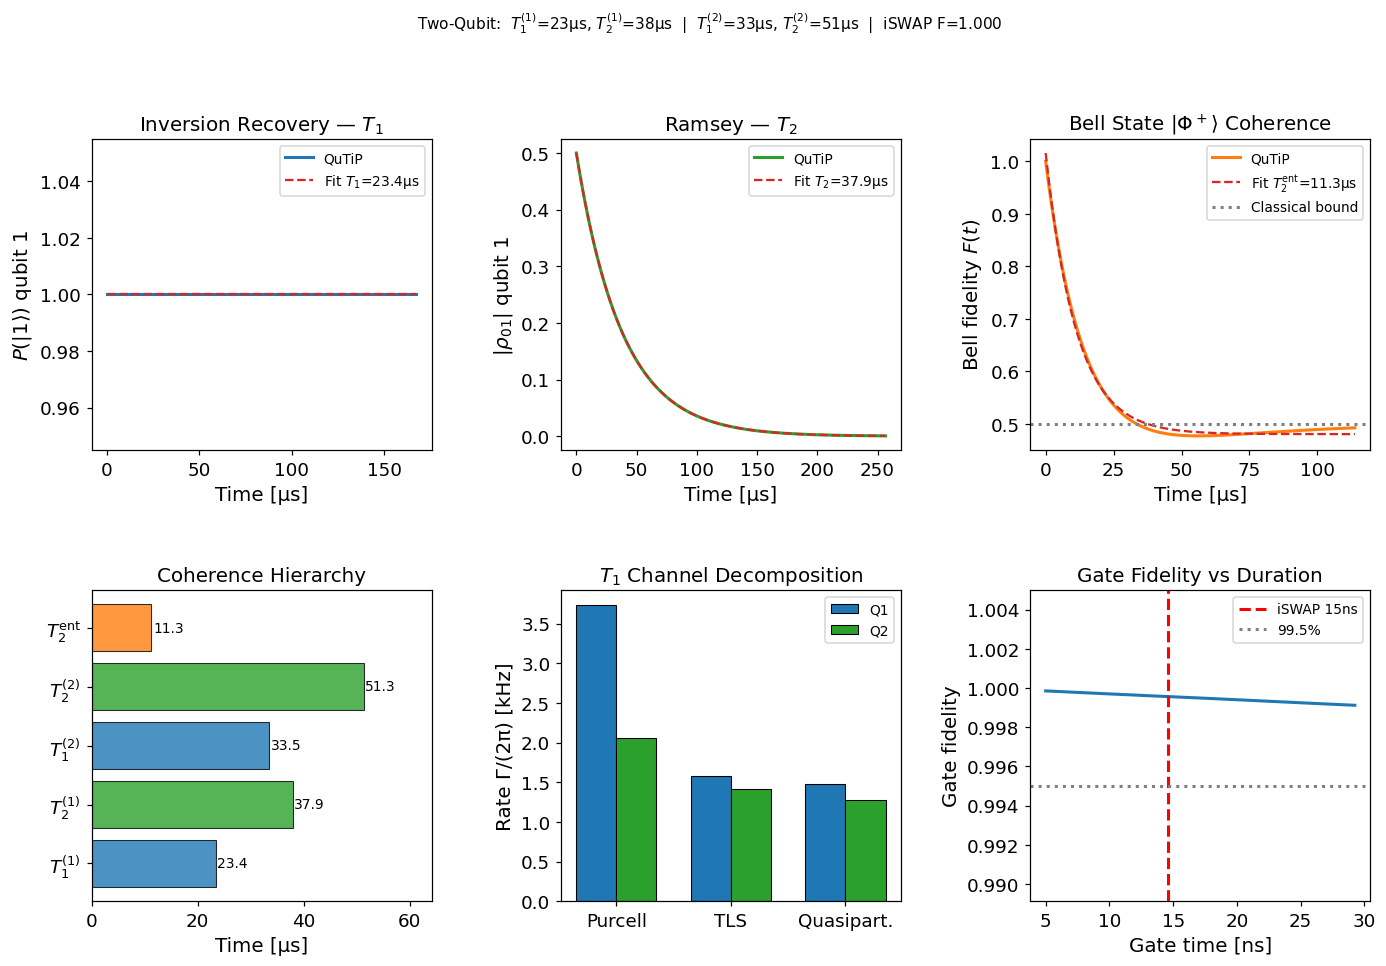

Saved: /Users/farukakbar/Downloads/files/two_qubit_summary.png


In [14]:
fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Panel 1: T1 inversion recovery
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(t_T1*1e6, P1_t, 'C0', label='QuTiP')
ax1.plot(t_T1*1e6, exp_decay(t_T1,*popt_T1), 'C3--', lw=1.5,
         label=f'Fit $T_1$={T1_fitted*1e6:.1f}μs')
ax1.set_xlabel('Time [μs]'); ax1.set_ylabel('$P(|1\\rangle)$ qubit 1')
ax1.set_title('Inversion Recovery — $T_1$'); ax1.legend(fontsize=9)

# Panel 2: T2 Ramsey
ax2 = fig.add_subplot(gs[0,1])
ax2.plot(t_T2*1e6, coh1_t, 'C2', label='QuTiP')
ax2.plot(t_T2*1e6, exp_decay(t_T2,*popt_T2), 'C3--', lw=1.5,
         label=f'Fit $T_2$={T2_fitted*1e6:.1f}μs')
ax2.set_xlabel('Time [μs]'); ax2.set_ylabel('$|\\rho_{01}|$ qubit 1')
ax2.set_title('Ramsey — $T_2$'); ax2.legend(fontsize=9)

# Panel 3: Bell state
ax3 = fig.add_subplot(gs[0,2])
ax3.plot(t_bell*1e6, F_bell_t, 'C1', label='QuTiP')
ax3.plot(t_bell*1e6, exp_decay(t_bell,*popt_bell), 'C3--', lw=1.5,
         label=f'Fit $T_2^\\text{{ent}}$={T2ent_fitted*1e6:.1f}μs')
ax3.axhline(0.5, color='gray', ls=':', label='Classical bound')
ax3.set_xlabel('Time [μs]'); ax3.set_ylabel('Bell fidelity $F(t)$')
ax3.set_title('Bell State $|\\Phi^+\\rangle$ Coherence'); ax3.legend(fontsize=9)

# Panel 4: Coherence hierarchy
ax4 = fig.add_subplot(gs[1,0])
lbls=['$T_1^{(1)}$','$T_2^{(1)}$','$T_1^{(2)}$','$T_2^{(2)}$','$T_2^\\text{ent}$']
vals=[T1_1*1e6, T2_1*1e6, T1_2*1e6, T2_2*1e6, T2ent_fitted*1e6]
cols=['C0','C2','C0','C2','C1']
bars=ax4.barh(lbls,vals,color=cols,alpha=0.8,edgecolor='k',lw=0.7)
for b,v in zip(bars,vals):
    ax4.text(v+0.3,b.get_y()+b.get_height()/2,f'{v:.1f}',va='center',fontsize=9)
ax4.set_xlabel('Time [μs]'); ax4.set_title('Coherence Hierarchy')
ax4.set_xlim(0,max(vals)*1.25)

# Panel 5: T1 channel breakdown
ax5 = fig.add_subplot(gs[1,1])
x=np.arange(3); w=0.35
r1=[ch1['Purcell'],ch1['TLS'],ch1['QP']]
r2=[ch2['Purcell'],ch2['TLS'],ch2['QP']]
ax5.bar(x-w/2,[r/(2*np.pi*1e3) for r in r1],w,label='Q1',color='C0',edgecolor='k',lw=0.7)
ax5.bar(x+w/2,[r/(2*np.pi*1e3) for r in r2],w,label='Q2',color='C2',edgecolor='k',lw=0.7)
ax5.set_xticks(x); ax5.set_xticklabels(['Purcell','TLS','Quasipart.'])
ax5.set_ylabel('Rate Γ/(2π) [kHz]')
ax5.set_title('$T_1$ Channel Decomposition'); ax5.legend(fontsize=9)

# Panel 6: Gate fidelity vs gate time (short scan)
ax6 = fig.add_subplot(gs[1,2])
t_scan_ns = np.linspace(5, min(500, t_iSWAP*2e9), 30)
F_scan = []
for tg_ns in t_scan_ns:
    tg = tg_ns*1e-9
    tg_list = np.linspace(0,tg,50)
    fs=[]
    for ket_in in input_states:
        rho_in=ket_in*ket_in.dag()
        # Ideal unitary at this time
        phi_ex = J_gate*tg  # exchange angle (rad), J_gate in rad/s
        U_mat = np.array([[1,0,0,0],
                          [0,np.cos(phi_ex),-1j*np.sin(phi_ex),0],
                          [0,-1j*np.sin(phi_ex),np.cos(phi_ex),0],
                          [0,0,0,1]])
        U_ideal=qt.Qobj(U_mat,dims=[[2,2],[2,2]])
        rho_ideal=U_ideal*rho_in*U_ideal.dag()
        res=qt.mesolve(H_gate,rho_in,tg_list,c_ops_idle,
                       options={'nsteps':5000,'atol':1e-7,'rtol':1e-5})
        fs.append((rho_ideal*res.states[-1]).tr().real)
    F_scan.append((4*np.mean(fs)+1)/5)

ax6.plot(t_scan_ns, F_scan, 'C0')
ax6.axvline(t_iSWAP*1e9, color='red', ls='--', label=f'iSWAP {t_iSWAP*1e9:.0f}ns')
ax6.axhline(0.995, color='gray', ls=':', label='99.5%')
ax6.set_xlabel('Gate time [ns]'); ax6.set_ylabel('Gate fidelity')
ax6.set_title('Gate Fidelity vs Duration'); ax6.legend(fontsize=9)
ax6.set_ylim(max(0.9,min(F_scan)-0.01), 1.005)

plt.suptitle(
    f'Two-Qubit:  $T_1^{{(1)}}$={T1_1*1e6:.0f}μs, $T_2^{{(1)}}$={T2_1*1e6:.0f}μs  |  '
    f'$T_1^{{(2)}}$={T1_2*1e6:.0f}μs, $T_2^{{(2)}}$={T2_2*1e6:.0f}μs  |  '
    f'iSWAP F={F_gate:.3f}',
    fontsize=10, y=1.01
)
savepath = os.path.join(OUTDIR,'two_qubit_summary.png')
plt.savefig(savepath, bbox_inches='tight', dpi=130)
plt.show()
print(f'Saved: {savepath}')

---
## 13. Full Numerical Summary

In [15]:
print('═'*65)
print('  TWO-QUBIT SYSTEM SUMMARY')
print('═'*65)
print(f'  JUNCTIONS  [MAT+GEOM]')
for nm,RN,EJ,EC in [('Q1',R_N1,E_J1,E_C1),('Q2',R_N2,E_J2,E_C2),('Coupler',R_Nc,E_Jc,E_Cc)]:
    print(f'    {nm}: R_N={RN:.0f}Ω  E_J/(2π)={EJ/h*1e-9:.2f}GHz  E_C/(2π)={EC/h*1e-9*1e3:.0f}MHz  E_J/E_C={EJ/EC:.0f}')
print(f'  FREQUENCIES')
print(f'    f_01 Q1 = {omega1/(2*np.pi*1e9):.4f} GHz')
print(f'    f_01 Q2 = {omega2/(2*np.pi*1e9):.4f} GHz    δ₁₂ = {(omega1-omega2)/(2*np.pi*1e6):.1f} MHz')
print(f'  COUPLING  [GEOMETRY]')
print(f'    g₁/(2π)={g1/(2*np.pi*1e6):.1f}MHz  g₂/(2π)={g2/(2*np.pi*1e6):.1f}MHz  g₁₂/(2π)={g12/(2*np.pi*1e6):.2f}MHz')
print(f'    J_eff at OFF/(2π) = {J_off/(2*np.pi*1e3):.2f} kHz  ← idle')
print(f'    ζ_eff at OFF/(2π) = {zeta_off/(2*np.pi*1e3):.3f} kHz  ← residual ZZ')
print(f'    J_eff at GATE/(2π) = {J_gate/(2*np.pi*1e6):.1f} MHz')
print(f'  COHERENCE (from Lindblad fit)')
print(f'    T₁ Q1 = {T1_fitted*1e6:.2f} μs    T₁ Q2 = {T1_2*1e6:.2f} μs')
print(f'    T₂ Q1 = {T2_fitted*1e6:.2f} μs    T₂ Q2 = {T2_2*1e6:.2f} μs')
print(f'    T₂ (Bell |Φ+⟩) = {T2ent_fitted*1e6:.2f} μs  < min(T₂)={min(T2_1,T2_2)*1e6:.2f} μs')
print(f'  GATE')
print(f'    iSWAP gate time = {t_iSWAP*1e9:.0f} ns')
print(f'    iSWAP fidelity  = {F_gate:.4f}  ({(1-F_gate)*100:.3f}% error)')
print('═'*65)
print()
print('NOTES ON THE COHERENCE TIMES:')
print(f'  Q1 has shorter T1/T2 than Q2 — this is NOT caused by the two-qubit coupling.')
print(f'  It is because Q1 has a smaller junction (R_N1={R_N1:.0f}Ω < R_N2={R_N2:.0f}Ω):')
print(f'    Smaller R_N → larger E_J → higher f_01 ({omega1/(2*np.pi*1e9):.3f} vs {omega2/(2*np.pi*1e9):.3f} GHz)')
print(f'    Higher f_01 → faster TLS decay (Γ_TLS ∝ ω_01)')
print(f'    Higher f_01 → faster QP decay (Γ_qp ∝ E_J)')
print(f'  The idle coupling (J_eff≈0, ζ_eff≈0) does NOT shorten single-qubit T1/T2.')
print(f'  The ONLY new two-qubit decoherence effect at idle is the Bell state:')
print(f'    T2_ent = {T2ent_fitted*1e6:.1f} μs < min(T2) = {min(T2_1,T2_2)*1e6:.1f} μs')
print(f'    because BOTH qubits must stay coherent simultaneously.')
print(f'  If you want Q1 and Q2 to have similar coherence times, make R_N1 ≈ R_N2.')

═════════════════════════════════════════════════════════════════
  TWO-QUBIT SYSTEM SUMMARY
═════════════════════════════════════════════════════════════════
  JUNCTIONS  [MAT+GEOM]
    Q1: R_N=9000Ω  E_J/(2π)=14.74GHz  E_C/(2π)=258MHz  E_J/E_C=57
    Q2: R_N=11000Ω  E_J/(2π)=12.06GHz  E_C/(2π)=258MHz  E_J/E_C=47
    Coupler: R_N=5000Ω  E_J/(2π)=26.53GHz  E_C/(2π)=352MHz  E_J/E_C=75
  FREQUENCIES
    f_01 Q1 = 5.2598 GHz
    f_01 Q2 = 4.7330 GHz    δ₁₂ = 526.8 MHz
  COUPLING  [GEOMETRY]
    g₁/(2π)=80.0MHz  g₂/(2π)=75.9MHz  g₁₂/(2π)=4.99MHz
    J_eff at OFF/(2π) = 11.00 kHz  ← idle
    ζ_eff at OFF/(2π) = -0.000 kHz  ← residual ZZ
    J_eff at GATE/(2π) = -17.1 MHz
  COHERENCE (from Lindblad fit)
    T₁ Q1 = 23.41 μs    T₁ Q2 = 33.45 μs
    T₂ Q1 = 37.92 μs    T₂ Q2 = 51.32 μs
    T₂ (Bell |Φ+⟩) = 11.30 μs  < min(T₂)=37.92 μs
  GATE
    iSWAP gate time = 15 ns
    iSWAP fidelity  = 0.9996  (0.044% error)
═════════════════════════════════════════════════════════════════

NOTES ON THE C

---
## 14. Sensitivity Analysis

Sensitivity $S = d\ln T / d\ln p$ — fractional change in $T_1$, $T_2$, $T_2^\text{ent}$ per fractional change in parameter.  
**New two-qubit channels** compared to single-qubit: $g_1$, $g_2$ (coupling), $C_{12}$ (direct stray), $R_{Nc}$ (coupler junction — controls OFF point quality).

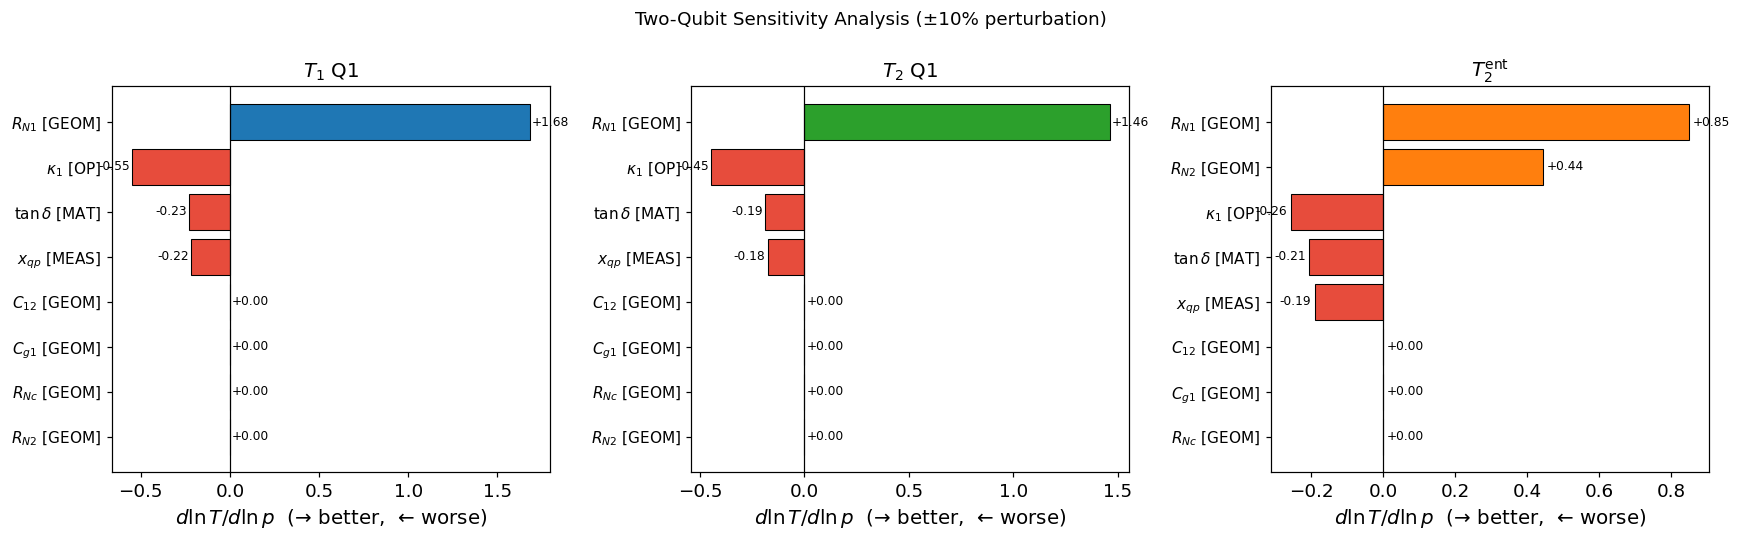


Parameter                  S(T1_Q1)  S(T2_Q1) S(T2_ent)
─────────────────────────────────────────────────────────
$R_{N1}$ [GEOM]              +1.682    +1.461    +0.850
$R_{N2}$ [GEOM]              +0.000    +0.000    +0.443
$\kappa_1$ [OP]              -0.551    -0.446    -0.256
$\tan\delta$ [MAT]           -0.232    -0.188    -0.205
$x_{qp}$ [MEAS]              -0.218    -0.177    -0.189
$R_{Nc}$ [GEOM]              +0.000    +0.000    +0.000
$C_{g1}$ [GEOM]              +0.000    +0.000    +0.000
$C_{12}$ [GEOM]              +0.000    +0.000    +0.000


In [16]:
def compute_coherence(R_N1_, R_N2_, R_Nc_, C_g1_, C_g2_, C_12_,
                      kappa1_, tan_delta_, p_surf_, x_qp_):
    """Return (T1_q1, T2_q1, T2_ent)."""
    EJ1_,EC1_,CS1_ = junction_params(R_N1_, C_J1, C_sh1)
    EJ2_,EC2_,CS2_ = junction_params(R_N2_, C_J2, C_sh2)
    EJc_,ECc_,CSc_ = junction_params(R_Nc_, C_Jc, C_shc)
    om1_,_  = transmon_freq(EJ1_, EC1_)
    om2_,_  = transmon_freq(EJ2_, EC2_)
    omc_,alc_ = transmon_freq(EJc_, ECc_)
    g1_ = (C_g1_/(2*np.sqrt(CS1_*CSc_)))*np.sqrt(om1_*omc_)
    g2_ = (C_g2_/(2*np.sqrt(CS2_*CSc_)))*np.sqrt(om2_*omc_)
    g12_= (C_12_/(2*np.sqrt(CS1_*CS2_)))*np.sqrt(om1_*om2_)
    # Find OFF point
    pfs=np.linspace(0,0.5,400)
    Js=[]
    for pf in pfs:
        EJce=EJc_*abs(np.cos(np.pi*pf))
        if EJce<1e-40: Js.append(np.nan); continue
        wcc=(np.sqrt(8*EJce*ECc_)-ECc_)/hbar
        D1=om1_-wcc; D2=om2_-wcc
        if abs(D1)<100e6*2*np.pi or abs(D2)<100e6*2*np.pi: Js.append(np.nan); continue
        Js.append(g1_*g2_/2*(1/D1+1/D2)+g12_)
    Js=np.array(Js); valid_=~np.isnan(Js)
    if not any(valid_): return T1_1, T2_1, T2_ent
    oi=np.argmin(np.abs(Js[valid_]))
    pf_off=pfs[valid_][oi]
    EJce=EJc_*abs(np.cos(np.pi*pf_off))
    wcc=(np.sqrt(8*EJce*ECc_)-ECc_)/hbar
    D1=om1_-wcc; D2=om2_-wcc
    if abs(D1)<1e6 or abs(D2)<1e6: zoff_=0
    else: zoff_=-(g1_**2*g2_**2/2)*(1/(D1**2*D2)+1/(D1*D2**2))/alc_
    # Rates
    omr1=2*np.pi*f_r1; D_qr1=om1_-omr1
    gr1=(C_c1/2)*np.sqrt(om1_*omr1/(CS1_*C_r))
    G1_1_=(gr1/D_qr1)**2*kappa1_+p_surf_*om1_*tan_delta_+(8*EJ1_/(np.pi*hbar))*np.sqrt(2*Delta_sc/(hbar*om1_))*x_qp_
    dEJdP=-np.pi*EJ1_*np.sin(np.pi*flux_bias_qubits)/Phi0
    dwdEJ=np.sqrt(2*EC1_/EJ1_)/(2*hbar)
    Gfl1=abs(dwdEJ*dEJdP)*A_flux*np.sqrt(2*np.log(2))
    chi1=(gr1**2/D_qr1); nth1=1/(np.exp(hbar*omr1/(kB*T_fridge))-1)
    Gphi1_=Gfl1+8*chi1**2*nth1/kappa1_
    T1_1_=1/G1_1_; T2_1_=1/(G1_1_/2+Gphi1_)
    omr2=2*np.pi*f_r2; D_qr2=om2_-omr2
    gr2=(C_c2/2)*np.sqrt(om2_*omr2/(CS2_*C_r))
    G1_2_=(gr2/D_qr2)**2*kappa2+(p_surf_*om2_*tan_delta_)+(8*EJ2_/(np.pi*hbar))*np.sqrt(2*Delta_sc/(hbar*om2_))*x_qp_
    T1_2_=1/G1_2_
    dEJdP2=-np.pi*EJ2_*np.sin(np.pi*flux_bias_qubits)/Phi0
    dwdEJ2=np.sqrt(2*EC2_/EJ2_)/(2*hbar)
    Gfl2=abs(dwdEJ2*dEJdP2)*A_flux*np.sqrt(2*np.log(2))
    chi2=gr2**2/D_qr2; nth2=1/(np.exp(hbar*omr2/(kB*T_fridge))-1)
    Gphi2_=Gfl2+8*chi2**2*nth2/kappa2
    G2_2_=G1_2_/2+Gphi2_
    GZZ1_=2*zoff_**2*T1_2_
    T2e_=1/(G1_1_/2+Gphi1_+G2_2_+GZZ1_)
    return T1_1_, T2_1_, T2e_

base = compute_coherence(R_N1,R_N2,R_Nc,C_g1,C_g2,C_12,kappa1,tan_delta,p_surf,x_qp)
param_fns = {
    '$R_{N1}$ [GEOM]'    : lambda d: compute_coherence(R_N1*d,R_N2,R_Nc,C_g1,C_g2,C_12,kappa1,tan_delta,p_surf,x_qp),
    '$R_{N2}$ [GEOM]'    : lambda d: compute_coherence(R_N1,R_N2*d,R_Nc,C_g1,C_g2,C_12,kappa1,tan_delta,p_surf,x_qp),
    '$R_{Nc}$ [GEOM]'    : lambda d: compute_coherence(R_N1,R_N2,R_Nc*d,C_g1,C_g2,C_12,kappa1,tan_delta,p_surf,x_qp),
    '$C_{g1}$ [GEOM]'    : lambda d: compute_coherence(R_N1,R_N2,R_Nc,C_g1*d,C_g2,C_12,kappa1,tan_delta,p_surf,x_qp),
    '$C_{12}$ [GEOM]'    : lambda d: compute_coherence(R_N1,R_N2,R_Nc,C_g1,C_g2,C_12*d,kappa1,tan_delta,p_surf,x_qp),
    '$\\kappa_1$ [OP]'    : lambda d: compute_coherence(R_N1,R_N2,R_Nc,C_g1,C_g2,C_12,kappa1*d,tan_delta,p_surf,x_qp),
    '$\\tan\\delta$ [MAT]': lambda d: compute_coherence(R_N1,R_N2,R_Nc,C_g1,C_g2,C_12,kappa1,tan_delta*d,p_surf,x_qp),
    '$x_{qp}$ [MEAS]'    : lambda d: compute_coherence(R_N1,R_N2,R_Nc,C_g1,C_g2,C_12,kappa1,tan_delta,p_surf,x_qp*d),
}

delta=0.10; sens1,sens2,sense,names=[],[],[],[]
for name,fn in param_fns.items():
    rp=fn(1+delta); rm=fn(1-delta)
    sens1.append((rp[0]-rm[0])/(2*delta*base[0]))
    sens2.append((rp[1]-rm[1])/(2*delta*base[1]))
    sense.append((rp[2]-rm[2])/(2*delta*base[2]))
    names.append(name)

fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,sens,title,bc in zip(axes,[sens1,sens2,sense],
        ['$T_1$ Q1','$T_2$ Q1','$T_2^\\text{ent}$'],['C0','C2','C1']):
    idx=np.argsort(np.abs(sens))[::-1]
    sv=np.array(sens)[idx]; nl=np.array(names)[idx]
    bcs=[bc if s>=0 else '#e74c3c' for s in sv]
    ax.barh(range(len(sv)),sv,color=bcs,edgecolor='k',lw=0.7)
    ax.set_yticks(range(len(sv))); ax.set_yticklabels(nl,fontsize=10)
    ax.axvline(0,color='k',lw=0.8)
    ax.set_xlabel('$d\\ln T / d\\ln p$  (→ better,  ← worse)')
    ax.set_title(title); ax.invert_yaxis()
    for i,s in enumerate(sv):
        ax.text(s+0.01*np.sign(s) if s!=0 else 0.01,i,f'{s:+.2f}',
                va='center',fontsize=8,ha='left' if s>=0 else 'right')

plt.suptitle('Two-Qubit Sensitivity Analysis (±10% perturbation)',fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,'two_qubit_sensitivity.png'),bbox_inches='tight',dpi=130)
plt.show()

print(f'\n{"Parameter":<25}{"S(T1_Q1)":>10}{"S(T2_Q1)":>10}{"S(T2_ent)":>10}')
print('─'*57)
for n,s1,s2,se in sorted(zip(names,sens1,sens2,sense),key=lambda x:-abs(x[3])):
    print(f'{n:<25}{s1:>+10.3f}{s2:>+10.3f}{se:>+10.3f}')